**1. Suppose we collect data for a group of applicants to a data science bootcamp with variables:
• X1 = coding practice hours completed,
• X2 = prior programming experience (in years), and
• Y = admitted to the bootcamp.
We fit a logistic regression and produce estimated coefficients
β0 = −4.2, β1 = 0.04, and β2 = 0.8**

**(a) Estimate the probability that an applicant who has completed 60 hours of coding practice and has 2 years of programming experience is admitted to the bootcamp**

In [4]:
import numpy as np
#y = (-4.2) + 60(0.04) + 2(0.8)

y = -0.2

sigmoid = lambda z: 1/(1+np.exp(-y))

p = sigmoid(y)

print(f'probability = {p:.3f}')



probability = 0.450


**(b) How many practice hours would the applicant in part (a) need to study to have a 90% chance of being admitted?**

In [5]:
target = 0.90
logit = np.log(target/(1-target))
x1_needed = (logit - (-4.2) - (0.8)*2)/(0.04)

print(f'Hours needed for 90% chance of admittance = {x1_needed:.2f}')

Hours needed for 90% chance of admittance = 119.93


**(c) Describe in words the meaning of “β0 = −4.2” in the context of this model.**

β0 = −4.2 represents the model's intercept, so when a person has no years of programming experience and no practice hours coding, their admission probability is: e^(-4.2)/(1+e^(-4.2)) = 0.0148 = 1.48%

**2. As a first step, create two subsets of this data:
• Train, containing only records with StoreID 1, 2, 3, or 4, and
• Test, containing remaining records with StoreID 7.
We will use these subsets to predict Citrus Hill purchases.**

In [6]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from ISLP import load_data

OJ = load_data('OJ')

train_values = [1, 2, 3, 4]
Train = OJ[OJ['StoreID'].isin(train_values)]


test_values = [7]
Test = OJ[OJ['StoreID'].isin(test_values)]



**(a) In Train, locate three variables: Citrus Hill loyalty, indication of a Citrus Hill special, and price difference between the brands Calculate the mean, standard deviation, median, minimum value, and maximum value for each of these variables.**

In [7]:
loyalty = Train['LoyalCH']
loy_mean = loyalty.mean()
loy_median = loyalty.median()
loy_min = loyalty.min()
loy_max = loyalty.max()
loy_sd = loyalty.std()
print('Citrus Hill loyalty stats:')
print(f'Mean: {loy_mean}') 
print(f'Standard Deviation: {loy_sd}')
print(f'Median: {loy_median}')
print(f'Min: {loy_min}')
print(f'Max: {loy_max}')

special = Train['SpecialCH']
spec_mean = special.mean()
spec_median = special.median()
spec_min = special.min()
spec_max = special.max()
spec_sd = special.std()
print('\nCitrus Hill special stats:')
print(f'Mean: {spec_mean}') 
print(f'Standard Deviation: {spec_sd}')
print(f'Median: {spec_median}')
print(f'Min: {spec_min}')
print(f'Max: {spec_max}')

price_dif = Train['PriceDiff']
dif_mean = price_dif.mean()
dif_median = price_dif.median()
dif_min = price_dif.min()
dif_max = price_dif.max()
dif_sd = price_dif.std()
print('\nPrice Difference stats:')
print(f'Mean: {dif_mean}') 
print(f'Standard Deviation: {dif_sd}')
print(f'Median: {dif_median}')
print(f'Min: {dif_min}')
print(f'Max: {dif_max}')

Citrus Hill loyalty stats:
Mean: 0.5199879019607843
Standard Deviation: 0.3137571564198037
Median: 0.5
Min: 1.1e-05
Max: 0.999947

Citrus Hill special stats:
Mean: 0.046218487394957986
Standard Deviation: 0.2101051293520389
Median: 0.0
Min: 0
Max: 1

Price Difference stats:
Mean: 0.11452380952380951
Standard Deviation: 0.2559351252805437
Median: 0.2
Min: -0.67
Max: 0.44


**(b) Provide a correlation matrix for the three variables in (a).**

In [8]:
corr_vars = Train[['LoyalCH', 'SpecialCH', 'PriceDiff']]
corr_vars.corr().style.background_gradient(cmap='coolwarm')

,LoyalCH,SpecialCH,PriceDiff
LoyalCH,1.000000,0.014230,0.008349
SpecialCH,0.014230,1.000000,-0.025542
PriceDiff,0.008349,-0.025542,1.000000


**(c) Use the Train subset to perform a logistic regression with Purchase as the response and the three variables from (a) as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?**

In [33]:
X_full = sm.add_constant(corr_vars)
y_train = (Train["Purchase"]=="CH").astype(int)

model_full = sm.Logit(y_train, X_full).fit()
print("Logistic Regression Summary:")
print(model_full.summary())

sig_predictors = list(model_full.pvalues[model_full.pvalues < 0.05].index)
if "const" in sig_predictors:
    sig_predictors.remove("const")
print("Significant predictors:", sig_predictors)

Optimization terminated successfully.
         Current function value: 0.414155
         Iterations 7
Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:               Purchase   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.4009
Time:                        18:49:59   Log-Likelihood:                -295.71
converged:                       True   LL-Null:                       -493.55
Covariance Type:            nonrobust   LLR p-value:                 1.902e-85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4069      0.267    -12.756      0.000      -3.930      -2.883


**(d) Using Train and a probability threshold of 0.5, compute the confusion matrix and overall fraction of correct predictions. Also note the percent of false positives and the percent of false negatives.**

In [32]:
probs_train = model_full.predict(X_full)
preds_train = (probs_train >= 0.5).astype(int)
cm_train = confusion_matrix(y_train, preds_train, labels=[0,1])
tn, fp, fn, tp = cm_train.ravel()
acc = (tn+tp)/cm_train.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)
print("Train Confusion Matrix:")
print(cm_train)
print("Accuracy:", round(acc,4),
     "| False Positive %:", round(fp_rate,4),
     "| False Negative %:", round(fn_rate,4))

Train Confusion Matrix:
[[269  66]
 [ 62 317]]
Accuracy: 0.8207 | False Positive %: 0.197 | False Negative %: 0.1636


**(e) Now refit the logistic regression model on the Train data with only the significant predictors. For this model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [31]:
X_train_sig = sm.add_constant(Train[sig_predictors])
logit_sig = sm.Logit(y_train, X_train_sig).fit(disp=False)
X_test_sig = sm.add_constant(Test[sig_predictors])
y_test = (Test["Purchase"]=="CH").astype(int)
probs_test_logit = logit_sig.predict(X_test_sig)
preds_test_logit = (probs_test_logit >= 0.5).astype(int)
cm_e = confusion_matrix(y_test, preds_test_logit, labels=[0,1])
tn, fp, fn, tp = cm_e.ravel()
acc = (tn+tp)/cm_e.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)
print("Test Confusion (Logit, sig only):")
print(cm_e)
print("Accuracy:", round(acc,4),
     "| False Positive %:", round(fp_rate,4),
     "| False Negative %:", round(fn_rate,4))

Test Confusion (Logit, sig only):
[[ 60  22]
 [ 34 240]]
Accuracy: 0.8427 | False Positive %: 0.2683 | False Negative %: 0.1241


**(f) Use Naive Bayes on the Train data with only the significant predictors from (e). Use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [30]:
nb = GaussianNB()
nb.fit(Train[sig_predictors], y_train)
probs_nb = nb.predict_proba(Test[sig_predictors])[:,1]
preds_nb = (probs_nb >= 0.5).astype(int)
cm_f = confusion_matrix(y_test, preds_nb, labels=[0,1])
tn, fp, fn, tp = cm_f.ravel()
acc = (tn+tp)/cm_f.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)
print("Test Confusion (Naive Bayes):")
print(cm_f)
print("Accuracy:", round(acc,4),
     "| False Positive %:", round(fp_rate,4),
     "| False Negative %:", round(fn_rate,4))

Test Confusion (Naive Bayes):
[[ 64  18]
 [ 39 235]]
Accuracy: 0.8399 | False Positive %: 0.2195 | False Negative %: 0.1423


**(g) Build three k-Nearest Neighbors models on the Train data, using k = 5, 50, 150, and only the significant predictors from (e). For the k = 50 model, use Test to compute the confusion matrix, fraction of correct predictions, percent of false positives, and percent of false negatives.**

In [29]:
def knn_probs(k):
   knn = KNeighborsClassifier(n_neighbors=k)
   knn.fit(Train[sig_predictors], y_train)
   return knn.predict_proba(Test[sig_predictors])[:,1]
probs_knn50 = knn_probs(50)
preds_knn50 = (probs_knn50 >= 0.5).astype(int)
cm_g = confusion_matrix(y_test, preds_knn50, labels=[0,1])
tn, fp, fn, tp = cm_g.ravel()
acc = (tn+tp)/cm_g.sum()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp)
print("Test Confusion (kNN, k=50):")
print(cm_g)
print("Accuracy:", round(acc,4),
     "| False Positive %:", round(fp_rate,4),
     "| False Negative %:", round(fn_rate,4))

Test Confusion (kNN, k=50):
[[ 62  20]
 [ 40 234]]
Accuracy: 0.8315 | False Positive %: 0.2439 | False Negative %: 0.146


**(h) Provide a ROC curve for each of the five models in parts (e), (f), and (g) on the same plot. Which model yields the highest AUC?**

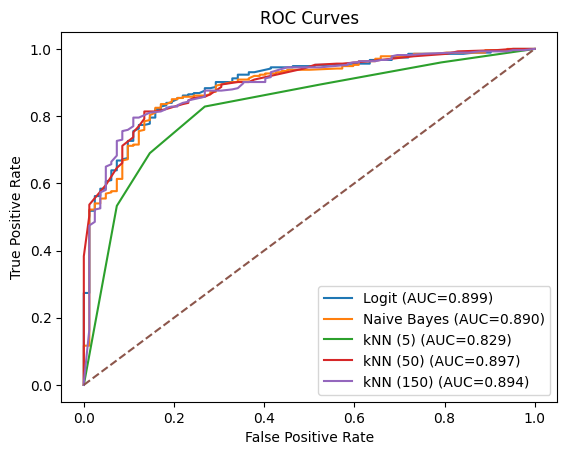

Highest AUC model: Logit | AUC = 0.8985


In [28]:
models = {
   "Logit": probs_test_logit,
   "Naive Bayes": probs_nb,
   "kNN (5)": knn_probs(5),
   "kNN (50)": probs_knn50,
   "kNN (150)": knn_probs(150)
}
plt.figure()
best_model, best_auc = None, -1
for name, probs in models.items():
   fpr, tpr, _ = roc_curve(y_test, probs)
   A = auc(fpr,tpr)
   plt.plot(fpr, tpr, label=f"{name} (AUC={A:.3f})")
   if A > best_auc:
       best_auc = A
       best_model = name
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("Highest AUC model:", best_model, "| AUC =", round(best_auc,4))

**3. In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features.**

In [15]:
# Data
points = np.array([
   [1,4],
   [1,3],
   [0,4],
   [5,1],
   [6,2],
   [4,0]
])

**(a) Plot the observations using a single color for all data points.**

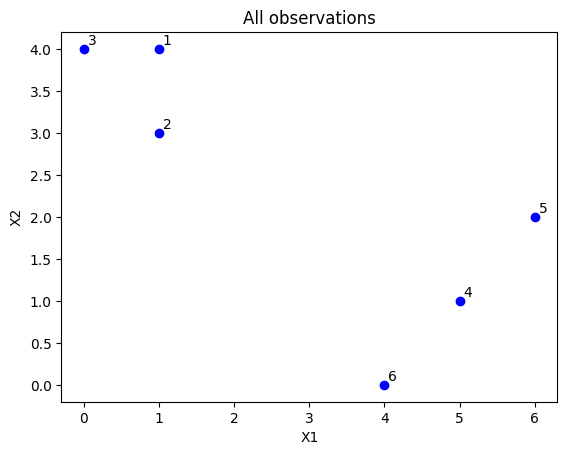

In [27]:
plt.figure()
plt.scatter(points[:,0], points[:,1], color='blue')
for i,(x,y) in enumerate(points, start=1):
   plt.text(x+0.05, y+0.05, str(i))
plt.title("All observations")
plt.xlabel("X1"); plt.ylabel("X2")
plt.show()

**(b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.**

In [17]:
rng = np.random.default_rng(42)
labels = rng.choice([0,1], size=len(points))
print("Initial random labels:", labels)
def compute_centroids(pts, lbls):
    cents = []
    for c in [0,1]:
        cents.append(pts[lbls == c].mean(axis=0))
    return np.array(cents)
def assign_to_nearest(pts, cents):
    new = []
    for p in pts:
        dists = np.linalg.norm(p - cents, axis=1) 
        new.append(np.argmin(dists))
    return np.array(new)

Initial random labels: [0 1 1 0 0 1]


**(c) Compute the centroid for each cluster.**

In [18]:
centroids = compute_centroids(points, labels)
print("Initial centroids:")
print(centroids)

Initial centroids:
[[4.         2.33333333]
 [1.66666667 2.33333333]]


**(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.**

In [19]:
new_labels = assign_to_nearest(points, centroids)
print("Reassigned labels (based on initial centroids):")
for i, lbl in enumerate(new_labels, start=1):
 print(f"Observation {i} → cluster {lbl}")

Reassigned labels (based on initial centroids):
Observation 1 → cluster 1
Observation 2 → cluster 1
Observation 3 → cluster 1
Observation 4 → cluster 0
Observation 5 → cluster 0
Observation 6 → cluster 0


**(e) Repeat (c) and (d) until the answers obtained stop changing.**

In [20]:
labels = new_labels 
while True:
    centroids = compute_centroids(points, labels)
    updated = assign_to_nearest(points, centroids)
    if np.array_equal(updated, labels):
       break
    labels = updated
print("FINAL stable cluster assignments:")
print(labels)
print("Final centroids:")
print(centroids)

FINAL stable cluster assignments:
[1 1 1 0 0 0]
Final centroids:
[[5.         1.        ]
 [0.66666667 3.66666667]]


**(f) In your plot from (a), color the observations according to the cluster labels obtained.**

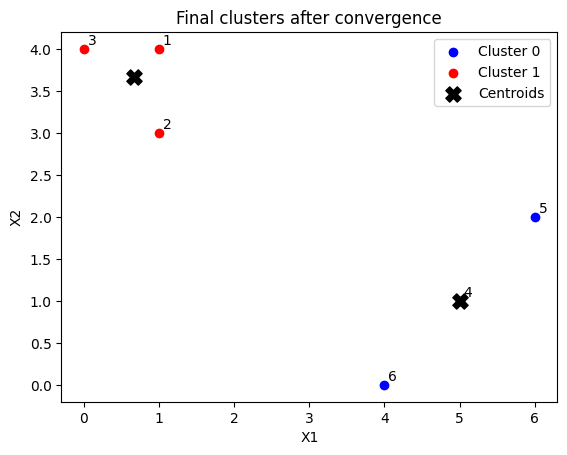

In [21]:
plt.figure()
plt.scatter(points[labels==0,0], points[labels==0,1], color='blue', label="Cluster 0")
plt.scatter(points[labels==1,0], points[labels==1,1], color='red',  label="Cluster 1")
for i,(x,y) in enumerate(points, start=1):
    plt.text(x+0.05, y+0.05, str(i))
plt.scatter(centroids[:,0], centroids[:,1], color='black', marker='X', s=120, label="Centroids")
plt.title("Final clusters after convergence")
plt.xlabel("X1"); plt.ylabel("X2")
plt.legend()
plt.show()

**4.**

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cev = pd.read_csv('../data/CEV2021.csv')

label_col = cev.columns[0]
numeric = cev.select_dtypes(include=[np.number]).copy()
mask_complete = numeric.dropna(axis=0, how='any').index
numeric = numeric.loc[mask_complete].reset_index(drop=True)
labels = cev.loc[mask_complete, label_col].astype(str).reset_index(drop=True)

**(a) Using hierarchical clustering with complete linkage and Euclidean distance, cluster the states. Report your answer with a dendrogram.**

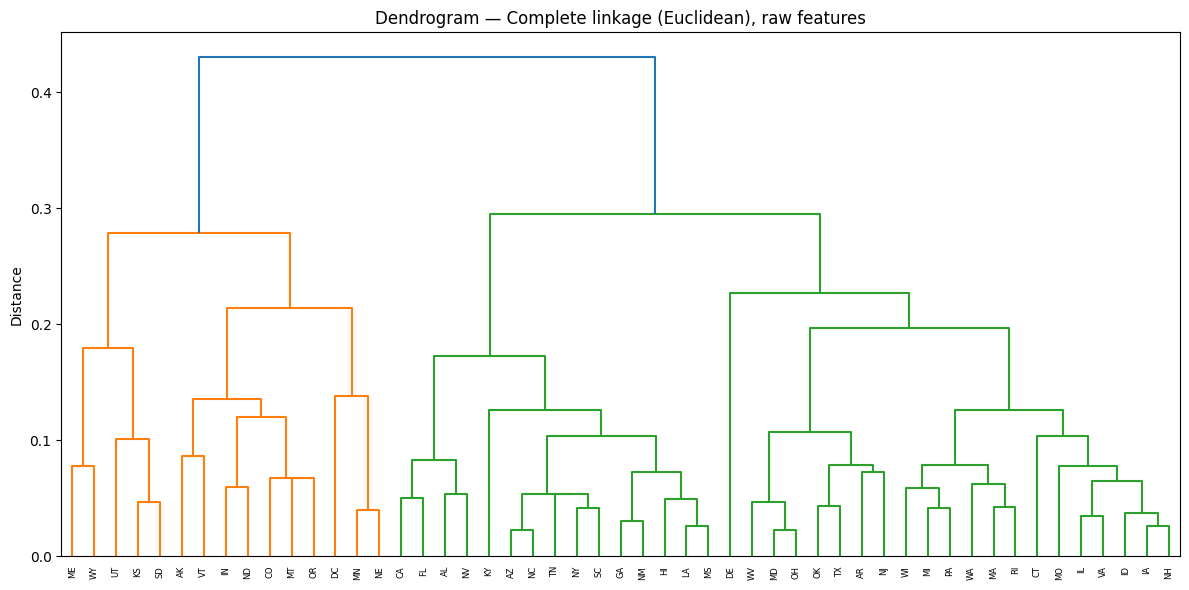

In [26]:
Z = linkage(numeric.values, method='complete', metric='euclidean')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=labels.values, leaf_rotation=90)
plt.title("Dendrogram — Complete linkage (Euclidean), raw features")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**(b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?**

In [25]:
clusters3 = fcluster(Z, t=3, criterion='maxclust')
df3 = pd.DataFrame({label_col: labels, "Cluster3": clusters3})
for c in sorted(df3["Cluster3"].unique()):
    print(f"Cluster {c} (3-cluster cut, raw):")
    print(df3.loc[df3["Cluster3"] == c, label_col].tolist())

Cluster 1 (3-cluster cut, raw):
['AK', 'CO', 'DC', 'IN', 'KS', 'ME', 'MN', 'MT', 'NE', 'ND', 'OR', 'SD', 'UT', 'VT', 'WY']
Cluster 2 (3-cluster cut, raw):
['AL', 'AZ', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MS', 'NV', 'NM', 'NY', 'NC', 'SC', 'TN']
Cluster 3 (3-cluster cut, raw):
['AR', 'CT', 'DE', 'ID', 'IL', 'IA', 'MD', 'MA', 'MI', 'MO', 'NH', 'NJ', 'OH', 'OK', 'PA', 'RI', 'TX', 'VA', 'WA', 'WV', 'WI']


**(c) Cut the dendrogram at a height that results in four distinct clusters. Which states belong to which clusters?**

In [34]:
clusters4 = fcluster(Z, t=4, criterion='maxclust')
df4 = pd.DataFrame({label_col: labels, "Cluster4": clusters4})
for c in sorted(df4["Cluster4"].unique()):
    print(f"\n(c) Cluster {c} (4-cluster cut, raw):")
    print(df4.loc[df4["Cluster4"] == c, label_col].tolist())


(c) Cluster 1 (4-cluster cut, raw):
['KS', 'ME', 'SD', 'UT', 'WY']

(c) Cluster 2 (4-cluster cut, raw):
['AK', 'CO', 'DC', 'IN', 'MN', 'MT', 'NE', 'ND', 'OR', 'VT']

(c) Cluster 3 (4-cluster cut, raw):
['AL', 'AZ', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MS', 'NV', 'NM', 'NY', 'NC', 'SC', 'TN']

(c) Cluster 4 (4-cluster cut, raw):
['AR', 'CT', 'DE', 'ID', 'IL', 'IA', 'MD', 'MA', 'MI', 'MO', 'NH', 'NJ', 'OH', 'OK', 'PA', 'RI', 'TX', 'VA', 'WA', 'WV', 'WI']


**(d) Use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?**

In [36]:
k3 = KMeans(n_clusters=3, n_init=25, random_state=0)
k_labels_raw = k3.fit_predict(numeric.values)
df_k3 = pd.DataFrame({label_col: labels, "KMeans3": k_labels_raw})
for c in sorted(df_k3["KMeans3"].unique()):
    print(f"K-means (raw) Cluster {c}:")
    print(df_k3.loc[df_k3["KMeans3"] == c, label_col].tolist())

K-means (raw) Cluster 0:
['AK', 'CO', 'DC', 'ME', 'MN', 'MT', 'NE', 'ND', 'OR', 'VT', 'WY']
K-means (raw) Cluster 1:
['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MD', 'MS', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'SC', 'TN', 'TX', 'WV']
K-means (raw) Cluster 2:
['CT', 'DE', 'ID', 'IL', 'IN', 'IA', 'KS', 'MA', 'MI', 'MO', 'NH', 'PA', 'RI', 'SD', 'UT', 'VA', 'WA', 'WI']


**(e) Repeat part (a), but first rescale and replace your variables so that they have mean 0 and standard deviation 1 (i.e., perform the clustering on the z-scores of the features, rather than the features themselves). Provide the new dendrogram.**

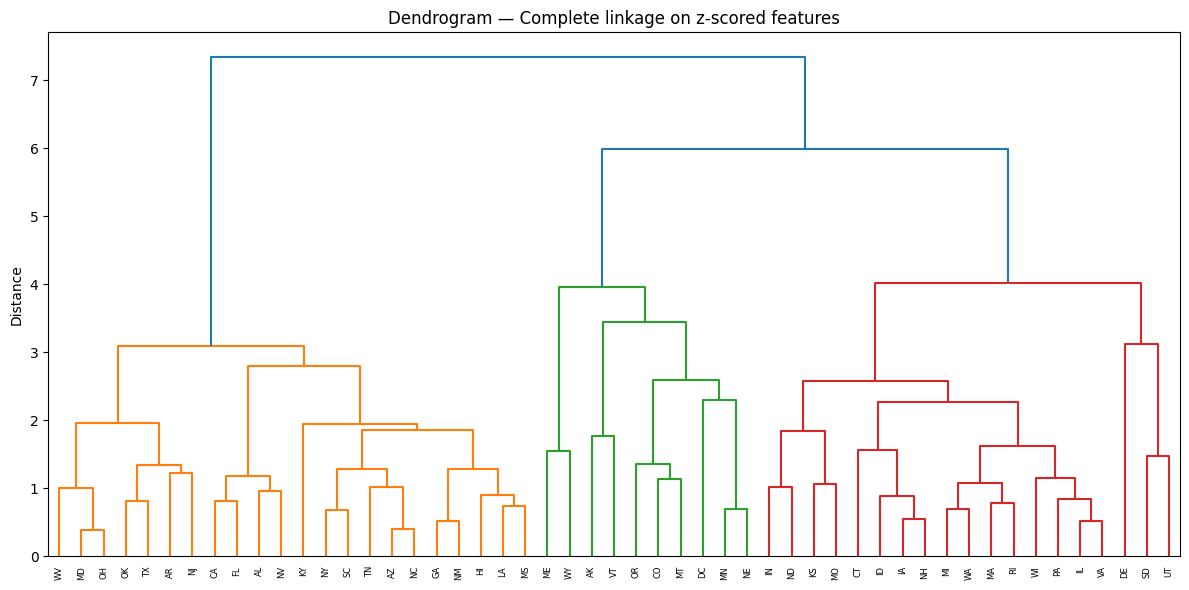

In [37]:
scaler = StandardScaler()
numeric_z = scaler.fit_transform(numeric.values)
Zz = linkage(numeric_z, method='complete', metric='euclidean')
plt.figure(figsize=(12, 6))
dendrogram(Zz, labels=labels.values, leaf_rotation=90)
plt.title("Dendrogram — Complete linkage on z-scored features")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**(f) Cut the new dendrogram from part (e) at a height that results in three distinct clusters. Which states belong to which clusters?**

In [ ]:
clusters3_z = fcluster(Zz, t=3, criterion='maxclust')
df3z = pd.DataFrame({label_col: labels, "Cluster3_Z": clusters3_z})
for c in sorted(df3z["Cluster3_Z"].unique()):
    print(f"\n(f) Cluster {c} (3-cluster cut, z-scored):")
    print(df3z.loc[df3z["Cluster3_Z"] == c, label_col].tolist())

**(g) Using the z-scores created in part (e), use K-means clustering and K = 3 to obtain new clusters of states. Which states belong to which clusters?**

In [39]:
k3z = KMeans(n_clusters=3, n_init=25, random_state=0)
k_labels_z = k3z.fit_predict(numeric_z)
df_k3z = pd.DataFrame({label_col: labels, "KMeans3_Z": k_labels_z})
for c in sorted(df_k3z["KMeans3_Z"].unique()):
    print(f"\n(g) K-means (z-score) Cluster {c}:")
    print(df_k3z.loc[df_k3z["KMeans3_Z"] == c, label_col].tolist())


(g) K-means (z-score) Cluster 0:
['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'HI', 'KY', 'LA', 'MD', 'MS', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK', 'SC', 'TN', 'TX', 'WV']

(g) K-means (z-score) Cluster 1:
['AK', 'CO', 'DC', 'ME', 'MN', 'MT', 'NE', 'OR', 'VT', 'WY']

(g) K-means (z-score) Cluster 2:
['CT', 'DE', 'ID', 'IL', 'IN', 'IA', 'KS', 'MA', 'MI', 'MO', 'NH', 'ND', 'PA', 'RI', 'SD', 'UT', 'VA', 'WA', 'WI']


**(h) Create a scatter plot of the states with axes Voting Local and Organization Membership which assigns a color to each point based on the clusters found in part (g).**

Using columns for scatter:
  Voting = 'Voting_Local'
  Organization = 'Organizational_Membership


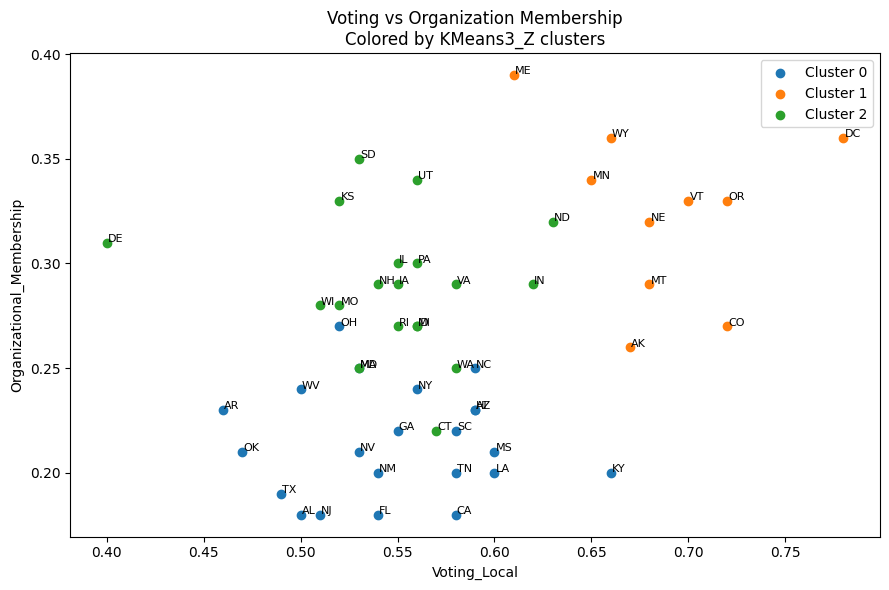

In [49]:
def _match_cols(columns, must_have_all):
    out = []
    for col in columns:
       low = col.lower()
       if all(k in low for k in must_have_all):
           out.append(col)
    return out

cols = list(cev.columns)

voting_candidates = (
   _match_cols(cols, ["vot", "local"]) or
   _match_cols(cols, ["local", "vot"]) or
   _match_cols(cols, ["local", "vote"]) or
   _match_cols(cols, ["local", "voting"])
)

org_candidates = (
   _match_cols(cols, ["org", "member"]) or
   _match_cols(cols, ["organiz", "member"]) or
   _match_cols(cols, ["organization", "membership"])
)

VOTING_COL = voting_candidates[0]
ORG_COL    = org_candidates[0]

print(f"Using columns for scatter:\n  Voting = '{VOTING_COL}'\n  Organization = '{ORG_COL}")

plot_df = cev.loc[mask_complete, [label_col, VOTING_COL, ORG_COL]].copy()
plot_df["KMeans3_Z"] = k_labels_z

plt.figure(figsize=(9, 6))
for c in sorted(plot_df["KMeans3_Z"].unique()):
    sub = plot_df[plot_df["KMeans3_Z"] == c]
    plt.scatter(sub[VOTING_COL], sub[ORG_COL], label=f"Cluster {c}")

for _, row in plot_df.iterrows():
    plt.text(row[VOTING_COL]*1.001, row[ORG_COL]*1.001, str(row[label_col]), fontsize=8)

plt.xlabel(VOTING_COL)
plt.ylabel(ORG_COL)
plt.title("Voting vs Organization Membership\nColored by KMeans3_Z clusters")
plt.legend()
plt.tight_layout()
plt.show()